In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import plotly.express as px
import matplotlib.pyplot as plt

## **Get & Preprocess Data**

We first try to investigate the date from the project, then we will moove to the real high frequency data.

#### 1. Project data

We can make the following remarks:
- there's a lot of time points, some times we find several prices for the same time, which seems confusing
- the log prices are discrete, they take only some specific value
- the log returns distributions has fat tails
  

In [15]:
Full_df = pd.DataFrame()
for i in range(25,26):
    df = pd.read_csv(f'data/Project_data/out{i}.csv')
    Full_df = pd.concat([Full_df,df])

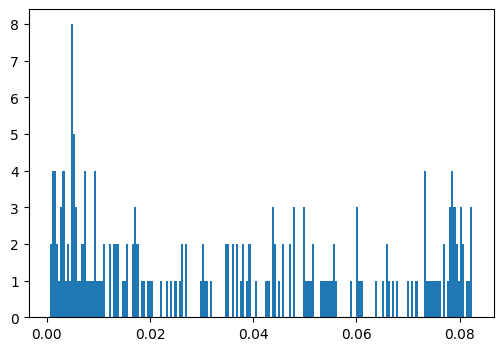

In [16]:
df_d1 = Full_df[Full_df['day']==1].copy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_d1.reset_index()['tick'].iloc[:200],bins = 200)
plt.show()

there's multiple log prices for the same tick, and no 

In [17]:

df_d1 = (
    df_d1.sort_values('tick').reset_index()
    .drop(columns='index')
    .set_index('tick')
    .assign(price=lambda df : np.exp(df['logprice']))
    .assign(logreturn=lambda df : df['logprice'].diff())
    .assign(RV = lambda df: df['logreturn'])
)


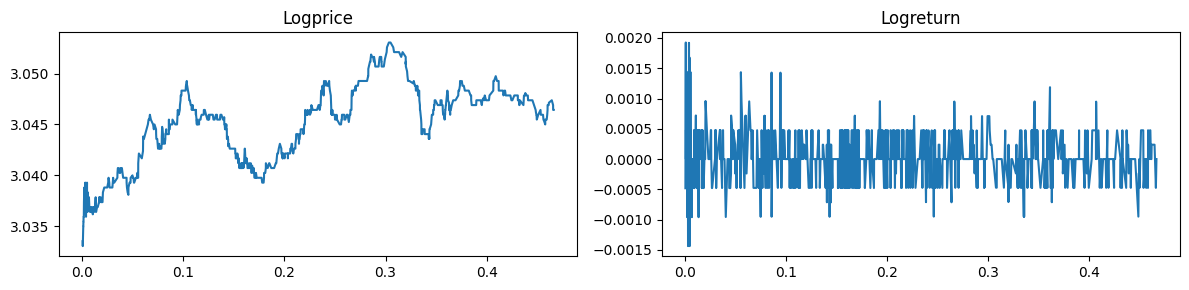

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(df_d1[['logprice']].iloc[:1000])
axes[0].set_title("Logprice")

# Right subplot
axes[1].plot(df_d1['logreturn'].iloc[:1000])
axes[1].set_title("Logreturn")

plt.tight_layout()
plt.show()

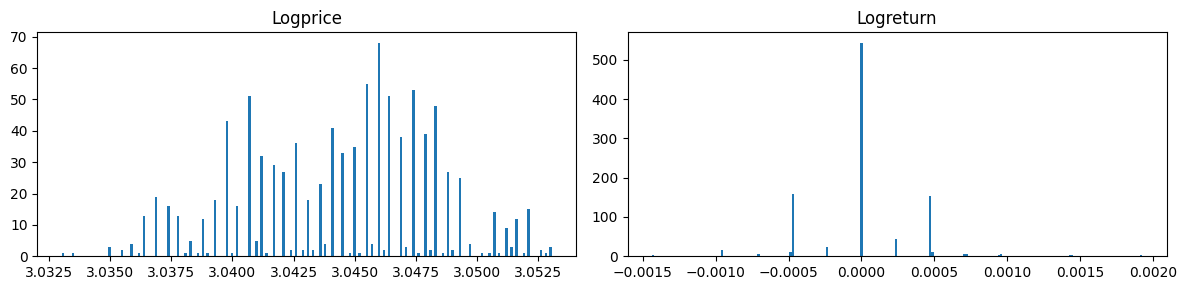

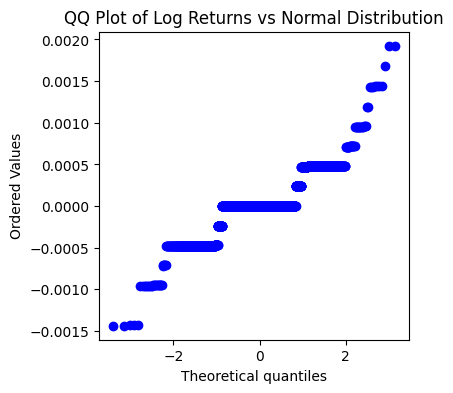

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].hist(df_d1[['logprice']].iloc[:1000],bins=200)
axes[0].set_title("Logprice")

# Right subplot
axes[1].hist(df_d1['logreturn'].iloc[:1000],bins=200)
axes[1].set_title("Logreturn")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(df_d1['logreturn'], dist="norm", plot=ax)
ax.set_title('QQ Plot of Log Returns vs Normal Distribution')
plt.show()


#### 2. LOBSTER Data

We know take some real high frequency market data, especially the foster dataset for MSFT prices on the 2012-06-21 day.

In [20]:
# Data Import
columns_ob = ['Ask','AskVolume','Bid','BidVolume']
df_ob = pd.read_csv('data/AMZN_2012-06-21_34200000_57600000_orderbook_1.csv',header=None,sep=';')
df_ob.columns = columns_ob

df_desc = pd.read_csv('data/AMZN_2012-06-21_34200000_57600000_message_1.csv',header=None)
df_desc.columns = ['Time','Type','OrderID','Size','Price','Direction']

raw_data = pd.concat([df_ob,df_desc],axis=1)
raw_data.head()

,Ask,AskVolume,Bid,BidVolume,Time,Type,OrderID,Size,Price,Direction
0,2239500,100,2231800,100,34200.017460,5,0,1,2238200,-1
1,2239500,100,2238100,21,34200.189608,1,11885113,21,2238100,1
2,2239500,100,2237500,100,34200.190226,4,11885113,21,2238100,1
3,2239500,100,2237500,74,34200.190226,4,11534792,26,2237500,1
4,2239500,100,2237500,74,34200.372780,5,0,100,2238400,-1


In [132]:
# Processing
data = ( 
    raw_data.copy()
    .assign(Ask=lambda df : df['Ask']/10000)
    .assign(Bid=lambda df : df['Bid']/10000)
    .assign(Price=lambda df : df['Price']/10000)
    .assign(mid=lambda df : (df['Ask']+df['Bid'])/2)
    .assign(logprice=lambda df : np.log(df['mid']))    
    .assign(logret=lambda df : df['logprice'].diff())    
    .assign(spread=lambda df : df['Ask']-df['Bid'])
    .assign(volumespread=lambda df : df['AskVolume']-df['BidVolume'])
)    

## **First Data Visualisation**

Variable descriptions:
- Bid, Ask,
- Prices (=mid price at first approx), log prices
- log returns : comparison with normal distribution
- Volume, BidVolume & AskVolume


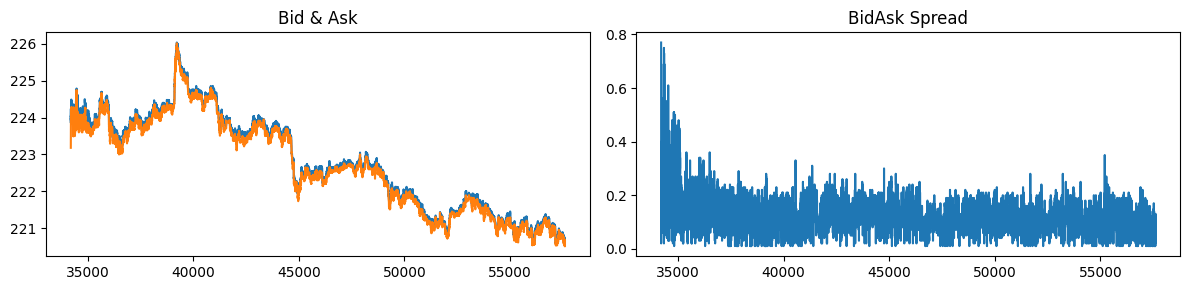

In [22]:
# First Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(data['Time'],data['Ask'])
axes[0].plot(data['Time'],data['Bid'])
axes[0].set_title("Bid & Ask")

# Right subplot
axes[1].plot(data['Time'], data['spread'])
axes[1].set_title('BidAsk Spread')

plt.tight_layout()
plt.show()

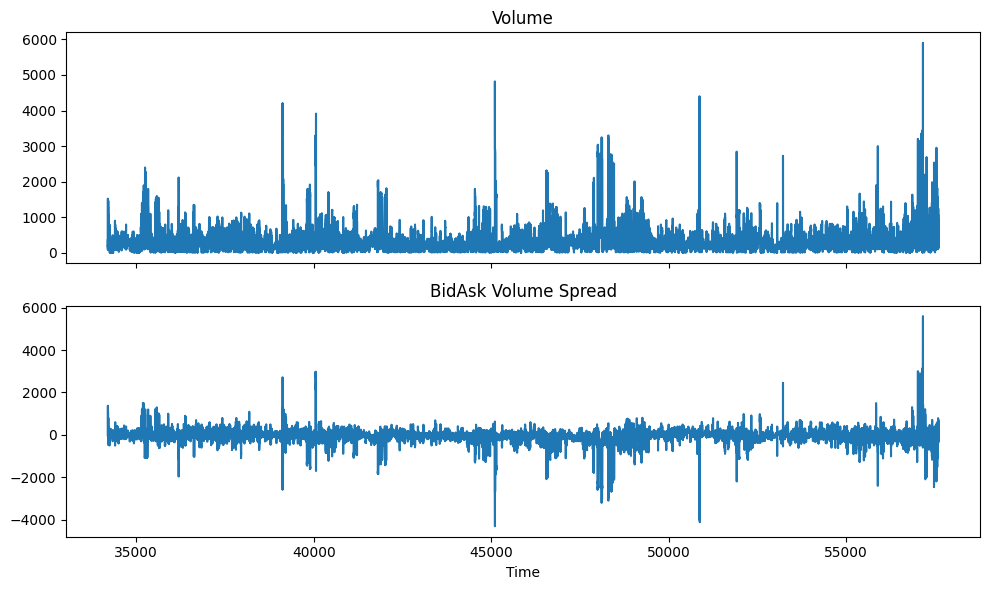

In [23]:
# first microstructure insights
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,6))

axes[0].plot(data['Time'],data['AskVolume'] + data['BidVolume'])
axes[0].set_title("Volume")


axes[1].plot(data['Time'], data['volumespread'])
axes[1].set_title('BidAsk Volume Spread')

plt.xlabel('Time')          # shared x-axis
plt.tight_layout()
plt.show()

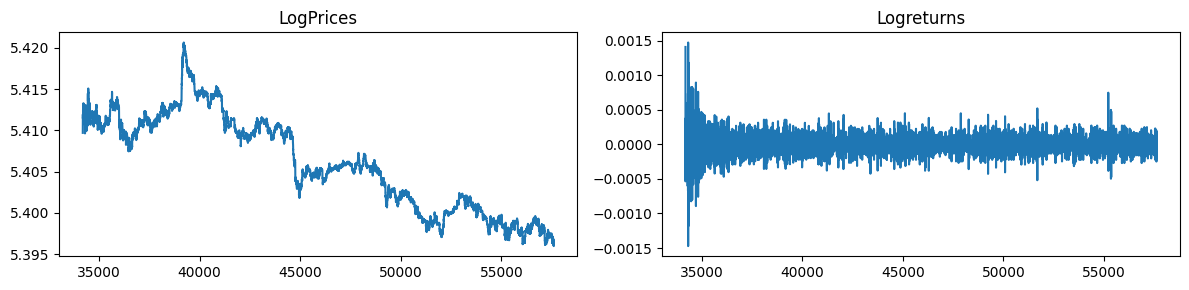

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(data['Time'], data[['logprice']])
axes[0].set_title("LogPrices")

# Right subplot
axes[1].plot(data['Time'], data['logret'])
axes[1].set_title("Logreturns")

plt.tight_layout()
plt.show()

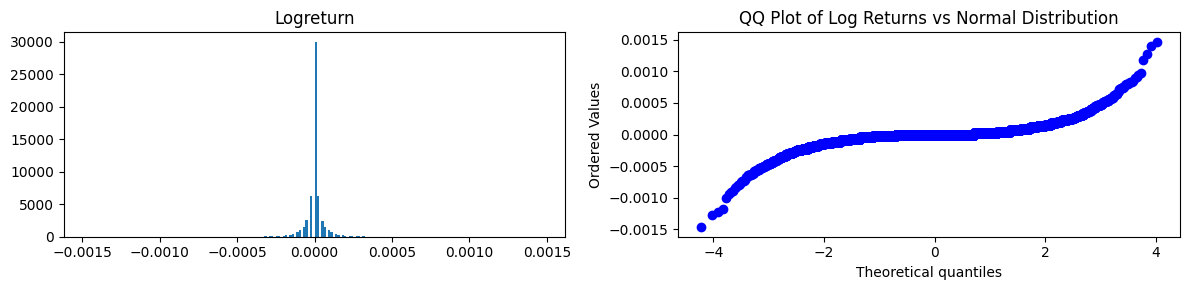

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(data['logret'],bins=200)
axes[0].set_title("Logreturn")

stats.probplot(data['logret'], dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot of Log Returns vs Normal Distribution')
plt.tight_layout()
plt.show()


## **No Noise modelling**

Let's assume the data has no microstructure (ie. no noise modelisation), and compute:
- realized variance
- spot volatility

We first to resample the prices, and to have the prices on a given grid of time. To do it we aggregate data using Vwap prices.

In [43]:
def vwap(df):
    '''
    Compute Vwap price
    '''
    vol = df['AskVolume'] + df['BidVolume']
    num = df['Ask'] * df['AskVolume'] + df['Bid'] * df['BidVolume']
    tot_vol = vol.sum()
    if tot_vol == 0:
        return np.nan   # no volume in this bin
    return num.sum() / tot_vol
    
def resample(data, T):
    """
    Resample DataFrame on calendar time with VWAP and previous-tick interpolation.

    data : pd.DataFrame with columns ['Time','Bid','BidVolume','Ask','AskVolume']
    T    : sampling period in seconds (int)
    """
    data = data.copy()
    data['Time'] = pd.to_datetime(data['Time'], unit='s')
    resampled = (
        data
        .set_index('Time')
        .resample(f'{T}s')
        .apply(vwap)
    )
    # Replace 0 or NaN by previous value (previous-tick interpolation)
    resampled = resampled.replace(0, np.nan).ffill()
    return resampled.dropna()

### **Realized Variance**

Computation of Realized variance for different sampling periods, we show that without noise modelling, the realized variance diverge to infinity while the sampling period is shrinking

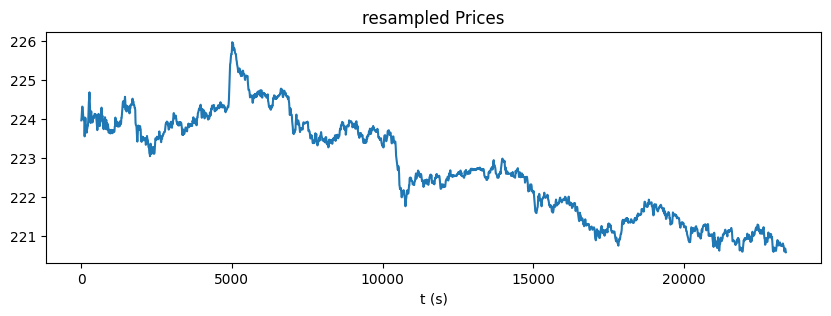

In [47]:
resampled_prices = (
    pd.DataFrame(resample(data,10))
    #.assign(Time = lambda df : df.index.strftime('%H:%M:%S'))
    .reset_index()
    .assign(Time = lambda df : df.index * 10)
    .rename(columns = {0:'mid'})
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(resampled_prices['Time'],resampled_prices['mid'])
ax.set_title('resampled Prices')
ax.set_xlabel('t (s)')
plt.show()

In [28]:
def get_RV(data,T):
    '''
    Compute Realized variance depending on sampling frequency
        data (pd.DataFrame) - price data
        T (int) - sampling period in second
    '''
    resampled_prices = resample(data,T)
    logret = np.log(resampled_prices).diff()
    RV = (logret**2).sum()
    return RV*100

RV_res = pd.read_excel('res\RV_res.xlsx',index_col=0)

#RV_res = []
#for i in range(1, 10, 1):
#    RV_res.append({'T_Sampling': i, 'RV': get_RV(data, i)})
#for i in range(10, 600, 10):
#    RV_res.append({'T_Sampling': i, 'RV': get_RV(data, i)})
#RV_res = pd.DataFrame(RV_res)

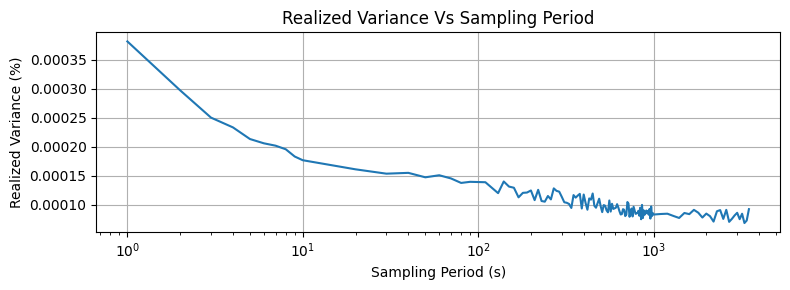

In [29]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(RV_res['T_Sampling'],RV_res['RV'])
ax.grid()
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel('Realized Variance (%)')
ax.set_title("Realized Variance Vs Sampling Period")
plt.tight_layout()
plt.show()

#### **VAR Computation**

Let's Naively compute the VAR on sampled on 1s scale. 

1. First make sure the returns are stationnary -> adfuller stationnarity test

In [30]:
sampled_prices = resample(data,1)

sampled_data = (
    pd.DataFrame(sampled_prices)
        .reset_index()
        .rename(columns={0:'mid'})
        .assign(logret=lambda df : (np.log(df['mid'])**2).diff())
        .dropna()
)

## **WRITE YOURSELF ADFULLLEEEERRR**

## **check if normal distribution**

In [31]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(sampled_data['logret'].dropna())
print('P_value :',adf_result[1]) 

P_value : 0.0


2. We can compute the empirical 5% quantile and the VAR(5%) estimator

In [32]:
from scipy.stats import norm

# Non Parametric VaR
var_5 = sampled_data['logret'].quantile(0.05)
print('Non Parametric VaR : ',var_5)

# Parametric VaR
RV = (sampled_data['logret']**2).sum()
var_norm_5 = RV * norm.ppf(0.05)
print('Parametric Normal VaR : ',var_norm_5)

Non Parametric VaR :  -0.0032266480070362036
Parametric Normal VaR :  -0.07337871224571015


**Backtest**

Since only one day is available, we cannot perform a proper out-of-sample VaR backtest.

However, we can approximate a pseudo-backtest by splitting the day into intraday windows (e.g., 30 min) and counting VaR exceptions inside the day.

- We clearly see that the parametric VaR is too conservative and overstating the risk

In [33]:
from sklearn.model_selection import KFold

sampled_prices = resample(data,1)

sampled_data = (
    pd.DataFrame(sampled_prices)
        .reset_index()
        .rename(columns={0:'mid'})
        .assign(logret=lambda df : (np.log(df['mid'])**2).diff())
        .dropna()
)

X = sampled_data['logret'].values
kf = KFold(n_splits=10)
kf.get_n_splits(X)

Res= []
for i, (train_index, test_index) in enumerate(kf.split(X)):
    train_index, test_index = test_index, train_index #too change the size of both
    
    var_5_non_param = np.quantile(X[train_index],0.05)
    non_param_exception_pct = (X[test_index]<var_5_non_param).mean()
    var_5_param = (X[train_index]**2).sum() * norm.ppf(0.05)
    param_exception_pct = (X[test_index]<var_5_param).mean()
    
    Res.append({'fold':i,'Non Par Var exceptions':non_param_exception_pct,
                'Param Var exceptions':param_exception_pct})

Res = pd.DataFrame(Res)

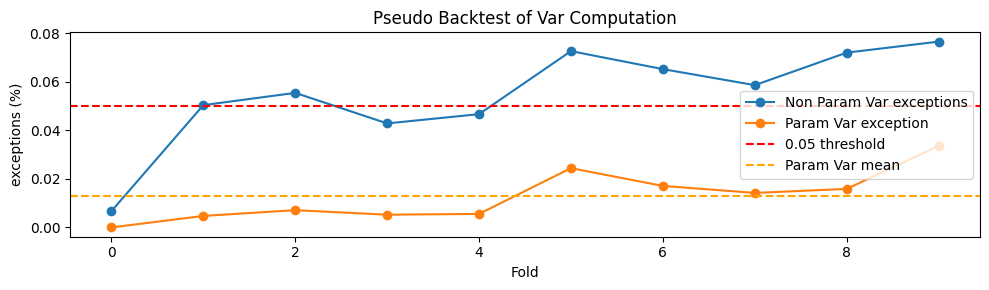

In [34]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(Res['fold'], Res['Non Par Var exceptions'], marker='o', label='Non Param Var exceptions')
ax.plot(Res['fold'], Res['Param Var exceptions'], marker='o', label='Param Var exception')
ax.axhline(0.05, linestyle='--', label='0.05 threshold', color = 'red')  # horizontal line
ax.axhline(Res['Param Var exceptions'].mean(), linestyle='--', label='Param Var mean', color = 'orange')

ax.set_xlabel('Fold')
ax.set_ylabel('exceptions (%)')
ax.set_title('Pseudo Backtest of Var Computation')
ax.legend()

plt.tight_layout()
plt.show()


### **Spot Volatility**

We can compute it using to method:
- moving average method
- kernel estimator (reputed to have a be a better estimator)

We differenciate two cases:
1. Computation of the window size in term of number of orders
2. Computation of the window size after resampling to 1s prices 

**Use of number of order to compute the windows :** 


#### LOOK AT ASSUPMPTION FOR KERNEL MOTIVATE THE CHOIC

In [35]:
def get_vol(data,window_size=50,method='kernel'):
    '''
    Compute spot volatility, 
    data (pd.DataFrame) - price data
    method (string) - method to estimate
    window_size (int) - number of observation to estimate
    '''
    if method == 'MA':
        vol = (
            data['logret'].rolling(window_size)
            .apply(lambda df : (df**2).sum())
            .dropna()
            /window_size
        )
        
    elif method == 'kernel':
        bandwidth = window_size / 6  
        vol = (
            data['logret']
            .rolling(window_size, min_periods=window_size)
            .apply(
                lambda x: (
                    norm.pdf(
                        (x.index.values - x.index.values[len(x)//2]) / bandwidth
                    ) * (x.values**2)
                ).sum()
                /window_size
            )
        )
    return vol*100

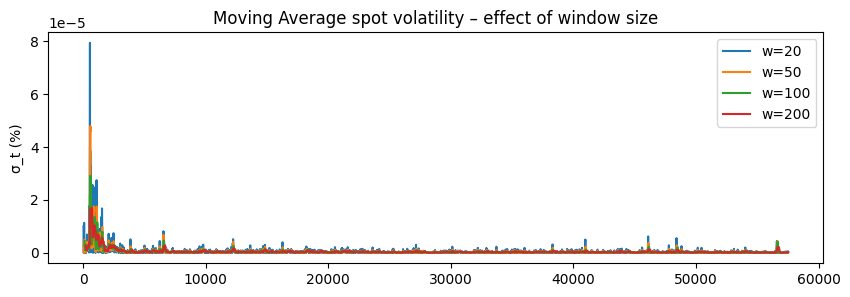

In [36]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [20, 50, 100, 200]:
    vol = get_vol(data, window_size=w, method='MA')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Moving Average spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

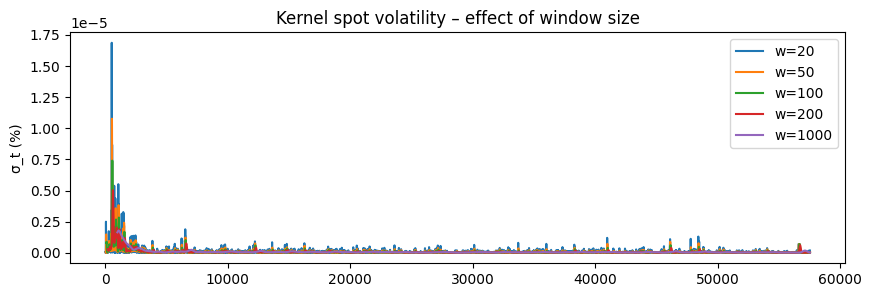

In [37]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [20, 50, 100, 200, 1000]:
    vol = get_vol(data, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

Text(0.5, 0, 'time')

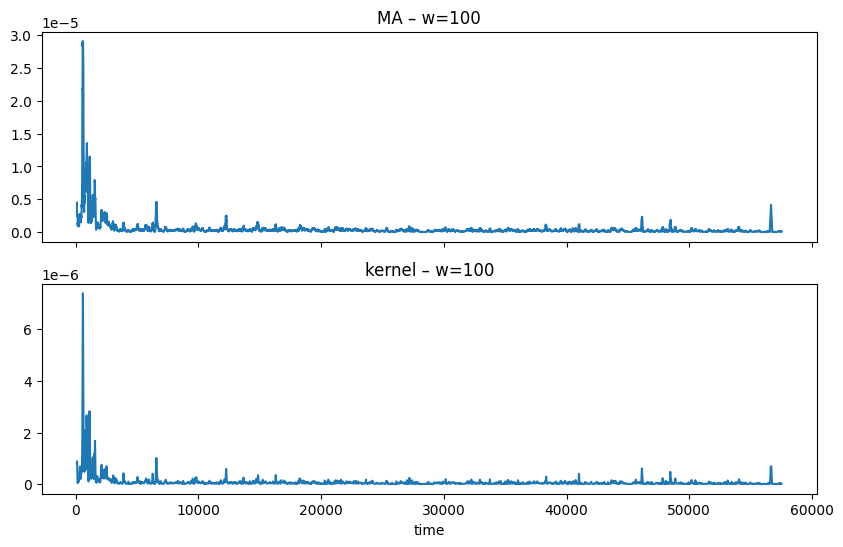

In [38]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

window_size = 100

for method, ax in zip(['MA', 'kernel'], axes):
    vol = get_vol(data, window_size=window_size, method=method)
    ax.plot(vol.index, vol)
    ax.set_title(f'{method} – w={window_size}')

axes[-1].set_xlabel('time')

**Use of time to compute the windows :** 

In [39]:
sampled_prices = resample(data,1)

sampled_logret = (
    pd.DataFrame(sampled_prices)
        .reset_index()
        .rename(columns={0:'mid'})
        .assign(logret=lambda df : (np.log(df['mid'])**2).diff())
        .dropna()
)

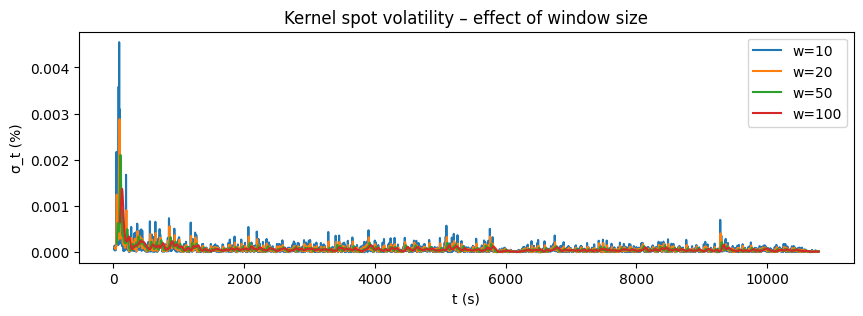

In [40]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [10, 20, 50, 100]:
    vol = get_vol(sampled_logret, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_xlabel('t (s)')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

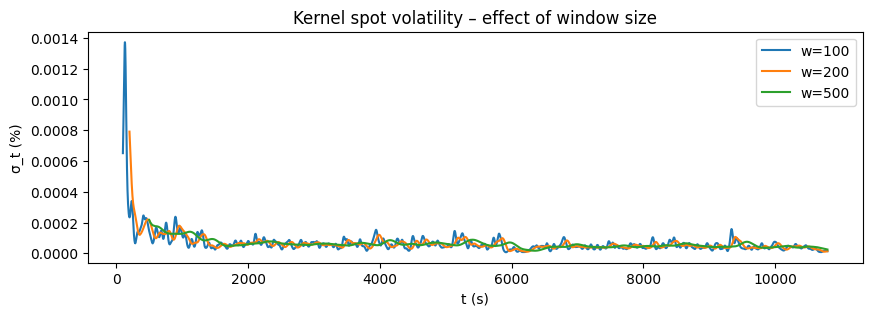

In [41]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [100, 200, 500]:
    vol = get_vol(sampled_logret, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_xlabel('t (s)')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

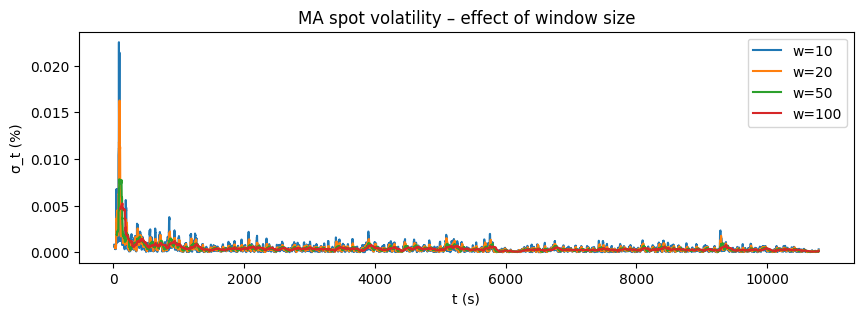

In [42]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [10, 20, 50, 100]:
    vol = get_vol(sampled_logret, window_size=w, method='MA')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('MA spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.set_xlabel('t (s)')
ax.legend()
plt.show()

## **Noise Modelling**

We first place ourself in the following model : $Y = X + \eta *\epsilon, \epsilon \sim \mathcal{N}(0,1)$.
1. Estimate $\eta$ using the $\frac{\widehat{RV_n}}{n}$ estimator
2. Estimate $\eta$ using the lag-1 autocovariance function

#### 1. $\frac{\widehat{RV_n}}{n}$ estimator

In [70]:
eta_res = []

for i in [i/2 for i in range(1, 20, 1)] + [i for i in range(10, 200, 10)]:
    n = 24000/i
    eta_est = np.sqrt(get_RV(data, i)/n/2)
    eta_res.append({'T_Sampling': i, 'eta_est': eta_est})

pd.DataFrame(eta_res).to_excel('res\eta_res_1.xlsx')
eta_res = pd.read_excel('res\eta_res_1.xlsx',index_col = 0)

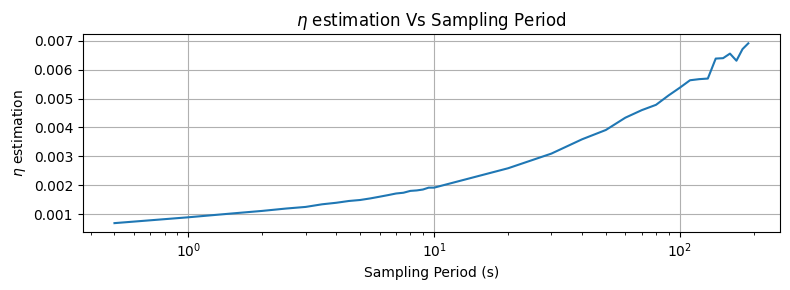

In [75]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(eta_res['T_Sampling'],eta_res['eta_est'])
ax.grid()
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel(r'$\eta$ estimation')
ax.set_title(r"$\eta$ estimation Vs Sampling Period")
plt.tight_layout()
plt.show()

#### 2. lag-1 autocovariance function

In [287]:
def lag1_autocov(data,T):
    """
    Compute sample lag-1 autocovariance
        data (pd.DataFrame) - price data
        T (int) - sampling period in second
    """
    x = resample(data,T)
    x = np.log(x)
    x = x.diff().dropna()
    mean = x.mean()
    return ((x.shift(0) - mean) * (x.shift(-1) - mean)).mean()

def rolling_autocov(x, window=200):
    """
    Rolling lag-1 autocovariance of series x.
    """
    x = pd.Series(x).dropna()
    mean = x.rolling(window).mean()

    cov = ((x.shift(0) - mean) * (x.shift(1) - mean)).rolling(window).mean()
    return cov



In [298]:
#eta_res_gamma1 = []

#for i in [i/4 for i in range(1, 40, 1)] :
#    n = 24000/i
#    gamma1 = lag1_autocov(data, i)
#    eta_est = 0
#    if gamma1<0:
#        eta_est = np.sqrt(-1*lag1_autocov(data, i))
#    eta_res_gamma1.append({'T_Sampling': i, 'eta_est': eta_est})

#pd.DataFrame(eta_res_gamma1).to_excel('res\eta_res_gamma.xlsx')


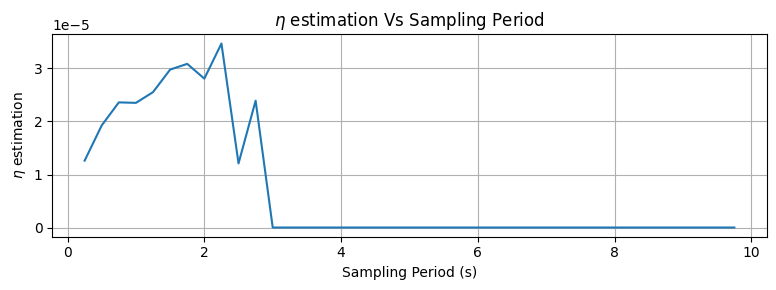

In [301]:
eta_res_gamma = pd.read_excel('res\eta_res_gamma.xlsx',index_col = 0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(eta_res_gamma['T_Sampling'],eta_res_gamma['eta_est'])
ax.grid()
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel(r'$\eta$ estimation')
ax.set_title(r"$\eta$ estimation Vs Sampling Period")
plt.tight_layout()
plt.show()

## **Considering only traded prices**

In [279]:
# select only trades
trades = (
    data[data['Type'].isin([4, 5])].copy()
    .assign(logret = lambda df:np.log(df['Price']).diff().dropna())
    .set_index('Time')
)

#### Rolling windows 

Text(0.5, 1.0, 'Rolling lag-1 autocovariance')

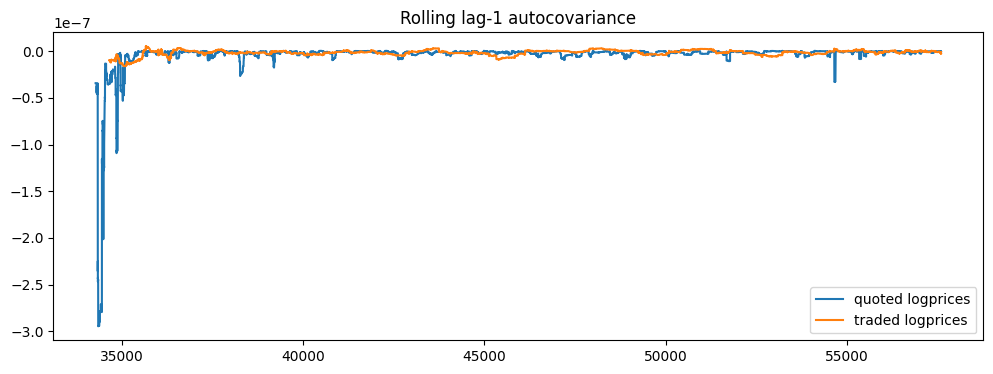

In [291]:
logret = np.log(data.set_index('Time')['Bid']).diff().dropna()
roll_cov = rolling_autocov(logret, window=200)


logret_trade = np.log(trades['Price']).diff().dropna()
roll_cov_trade = rolling_autocov(logret_trade, window=200)

fig = plt.figure(figsize = (12,4))
plt.plot(roll_cov,label='quoted logprices')
plt.plot(roll_cov_trade,label='traded logprices')
plt.legend()
plt.title('Rolling lag-1 autocovariance')

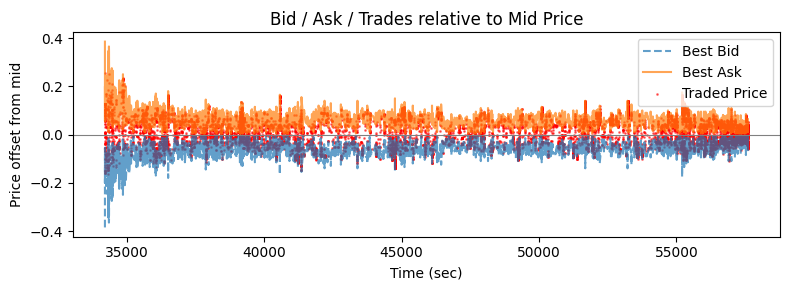

In [303]:
trades_cut = trades[trades.index < 1000000].copy()
fig, ax = plt.subplots(figsize=(8, 3))

# Bid and ask relative to mid
ax.plot(trades_cut.index, trades_cut['Bid'] - trades_cut['mid'] ,
        linestyle='--', label='Best Bid', alpha=0.7)
ax.plot(trades_cut.index, trades_cut['Ask'] - trades_cut['mid'],
        linestyle='-', label='Best Ask', alpha=0.7)

# Trades relative to mid
ax.scatter(trades_cut.index, trades_cut['Price'] - trades_cut['mid'],
           s=1, alpha = 0.5,color='red', label='Traded Price')

ax.axhline(0, color='grey', linewidth=0.8)  # mid = 0 line

ax.set_title("Bid / Ask / Trades relative to Mid Price")
ax.set_ylabel("Price offset from mid")
ax.set_xlabel("Time (sec)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


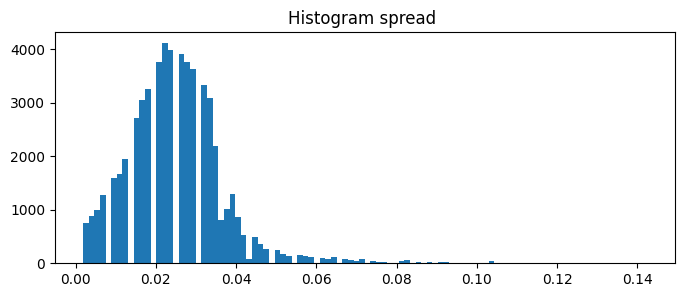

In [172]:
plt.figure(figsize=(8, 3))
plt.hist(data['spread']/data['logprice'], bins=100)
plt.title(r"Histogram spread ")
plt.show()


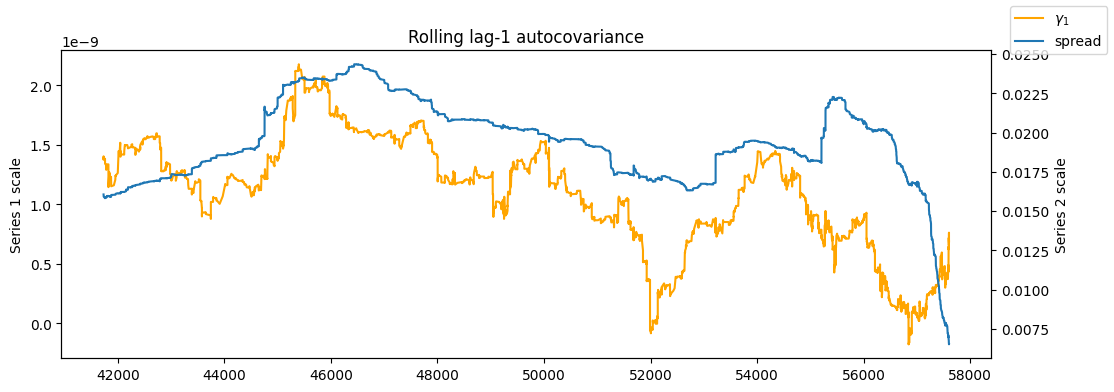

In [384]:
#logret = np.log(data.set_index('Time')['Bid']).diff().dropna()
#roll_cov = rolling_autocov(logret, window=200)
#plt.plot(roll_cov_trade,label='traded logprices')
window = 2000

logret_trade = np.log(trades['Price']).diff().dropna()
roll_cov_trade = - rolling_autocov(logret_trade, window=window)

fig, ax1 = plt.subplots(figsize = (12,4))
ax1.plot(roll_cov_trade,label=r'$\gamma_1$',color='orange')
ax1.set_ylabel('Series 1 scale')

ax2 = ax1.twinx() 
plt.plot((trades['spread']**2).iloc[window:].rolling(window).mean(),label='spread')
ax2.set_ylabel('Series 2 scale')
fig.legend()
plt.title('Rolling lag-1 autocovariance')
plt.show()

In [ ]:

def rolling_autocov(x, window=200):
    """
    Rolling lag-1 autocovariance of series x.
    """
    x = pd.Series(x).dropna()
    mean = x.rolling(window).mean()

    cov = ((x.shift(0) - mean) * (x.shift(1) - mean)).rolling(window).mean()
    return cov

In [367]:
window=100
x = np.log(trades['Price']).diff().dropna()
x = pd.Series(x).dropna()
mean = x.rolling(window).mean()

cov = ((x.shift(0) - mean) * (x.shift(1) - mean)).rolling(window).mean()


In [368]:
(x.shift(0) - mean) * (x.shift(1) - mean)

Time
34200.190226             NaN
34200.190226             NaN
34200.372780             NaN
34200.375671             NaN
34200.383971             NaN
                    ...     
57599.241762    1.943231e-08
57599.242004   -2.053001e-09
57599.402707   -4.191637e-09
57599.545828   -1.215295e-10
57599.545828    1.850661e-12
Name: Price, Length: 11418, dtype: float64

In [369]:
x = trades['spread'].dropna()
x = pd.Series(x).dropna()
spread = x.rolling(window).mean()

In [370]:
spread.dropna()

Time
34219.376645    0.2457
34219.516846    0.2400
34219.529936    0.2400
34221.596798    0.2401
34222.165293    0.2402
                 ...  
57599.241762    0.0777
57599.242004    0.0769
57599.402707    0.0769
57599.545828    0.0770
57599.545828    0.0771
Name: spread, Length: 11320, dtype: float64